In [37]:
import sys
!{sys.executable} -m pip install pandas numpy matplotlib seaborn scikit-learn langchain langgraph IPython

In [30]:
import pandas as pd
import numpy as np

In [31]:
from typing import TypedDict, Union
class movie(TypedDict):
    title: str
    genre: str
    rating: float

movies = [
    movie(title="Inception", genre="Sci-Fi", rating=8.8),
    movie(title="The Dark Knight", genre="Action", rating=9.0),
    movie(title="Pulp Fiction", genre="Crime", rating="hell")
]

def square(x: Union[int, float]) -> Union[int, float]:
    return x * x
print(square(5))  # Output: 25
print(square(3.14))  # Output: 9.8596
# print(square("hello"))  # wont work, type checker will catch this error

25
9.8596


In [32]:
movies

[{'title': 'Inception', 'genre': 'Sci-Fi', 'rating': 8.8},
 {'title': 'The Dark Knight', 'genre': 'Action', 'rating': 9.0},
 {'title': 'Pulp Fiction', 'genre': 'Crime', 'rating': 'hell'}]

**Langgraph hello world**

In [33]:
from typing import Dict,TypedDict
from langgraph.graph import StateGraph

In [50]:
class AgentState(TypedDict):
    name: str

def greeting_node(state: AgentState) -> AgentState:
    """ A simple node that takes an AgentState and returns a new AgentState with a greeting. """   
    state['name'] = "Hello, " + state['name']+ " how are you doing today?"
    return state

In [51]:
graph = StateGraph(AgentState)
graph.add_node("greeting_node", greeting_node)
graph.set_entry_point("greeting_node")
graph.set_finish_point("greeting_node")
app=graph.compile()

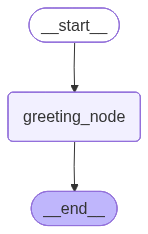

In [52]:
from IPython.display import display,Image
display(Image(app.get_graph().draw_mermaid_png()))

In [53]:
result = app.invoke({"name": "Alice"})
result['name']

'Hello, Alice how are you doing today?'

Multiple Input

In [54]:
from typing import Dict,TypedDict
from langgraph.graph import StateGraph

In [55]:
class AgentState(TypedDict):
    values: list[int]
    name: str
    result: str


def process_values_node(state: AgentState) -> AgentState:
    """ A node that processes the values in the state and updates the result. """
    total = sum(state['values'])
    state['result'] = f"The total is {total}"
    return state

In [56]:
graph = StateGraph(AgentState)
graph.add_node("process_values_node", process_values_node)
graph.set_entry_point("process_values_node")
graph.set_finish_point("process_values_node")
app=graph.compile()

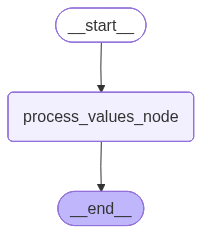

In [57]:
from IPython.display import display,Image
display(Image(app.get_graph().draw_mermaid_png()))

In [58]:
result = app.invoke({"values": [1, 2, 3], "name": "Alice", "result": ""})

In [ ]:
print(result)


{'values': [1, 2, 3], 'name': 'Alice', 'result': 'The total is 6'}


*Sequential graph*

In [62]:
from typing import Dict,TypedDict
from langgraph.graph import StateGraph

In [63]:
class AgentState(TypedDict):
    name: str
    age: int
    final: str

def first_node(state: AgentState) -> AgentState:
    state['final'] = f"AgentState: Hello, {state['name']}"
    return state

def second_node(state: AgentState) -> AgentState:
    state['final'] += f". You are {state['age']} years old."
    return state

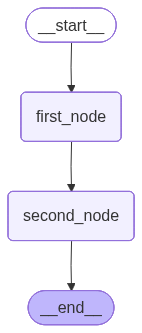

In [65]:
state_graph = StateGraph(AgentState)
state_graph.add_node("first_node", first_node)
state_graph.add_node("second_node", second_node)
state_graph.set_entry_point("first_node")
state_graph.add_edge("first_node", "second_node")
state_graph.set_finish_point("second_node")
app = state_graph.compile()
from IPython.display import display,Image
display(Image(app.get_graph().draw_mermaid_png()))


In [67]:
result=app.invoke({"name": "Alice", "age": 30, "final": ""})
result['final']
print(result['final'])
print(result)

AgentState: Hello, Alice. You are 30 years old.
{'name': 'Alice', 'age': 30, 'final': 'AgentState: Hello, Alice. You are 30 years old.'}


***Conditional Graph***

In [1]:
from typing import Dict,TypedDict
from langgraph.graph import StateGraph, START, END
class AgentState(TypedDict):
    number1: int
    operation: str
    number2: int
    finalNumber: int


def adder(state:AgentState) -> AgentState:
    state['finalNumber'] = state['number1'] + state['number2']
    return state

def subtractor(state:AgentState) -> AgentState:
    state['finalNumber'] = state['number1'] - state['number2']
    return state

def decider(state:AgentState) -> AgentState:
    if state['operation'] == 'add':
        return 'addition_operation'
    elif state['operation'] == 'subtract':
        return "subtraction_operation"
    else:
        raise ValueError("Invalid operation")
    return state

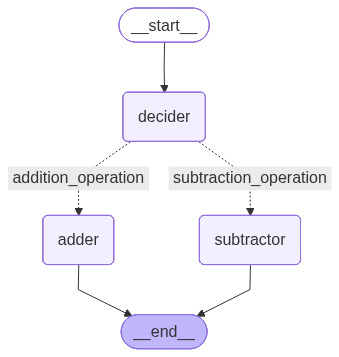

In [3]:
state_graph = StateGraph(AgentState)
state_graph.add_node("subtractor", subtractor)
state_graph.add_node("adder", adder)
state_graph.add_node("decider", lambda state: state)
state_graph.add_edge(START, "decider")
state_graph.add_conditional_edges("decider", decider, {'addition_operation': "adder", 'subtraction_operation': "subtractor"})
state_graph.add_edge("adder", END)
state_graph.add_edge("subtractor", END)
app = state_graph.compile()
from IPython.display import display,Image
display(Image(app.get_graph().draw_mermaid_png()))

In [4]:
initial_state_1=AgentState(
    number1=10,
    operation="add",
    number2=5
)

In [6]:
print(app.invoke(initial_state_1))

{'number1': 10, 'operation': 'add', 'number2': 5, 'finalNumber': 15}


***Graph V***

In [7]:
from langgraph.graph import StateGraph, START, END
import random
from typing import Dict,TypedDict

In [8]:
class AgentState(TypedDict):
    name: str
    number: list[int]
    counter: int

In [9]:
def greeting_node(state: AgentState) -> AgentState:
    state['name'] = "Hello, " + state['name']+ " how are you doing today?"
    state['counter'] =0
    return state

def random_number_node(state: AgentState) -> AgentState:
    state['number'].append(random.randint(1, 100))
    state['counter'] += 1
    return state

def should_continue_node(state: AgentState) -> AgentState:
    if state['counter'] < 5:
        print("entering loop",state['counter'])
        return "loop"
    else:
        return "exit"

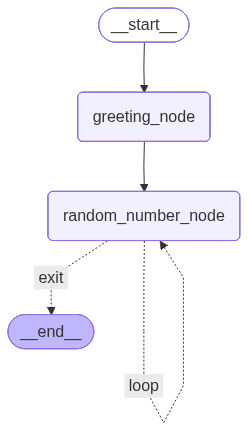

In [11]:
graph = StateGraph(AgentState)
graph.add_node("greeting_node", greeting_node)
graph.add_node("random_number_node", random_number_node)
graph.add_edge("greeting_node", "random_number_node")

graph.add_conditional_edges("random_number_node", should_continue_node,{"loop": "random_number_node", "exit": END})
graph.set_entry_point("greeting_node")
app = graph.compile()
from IPython.display import display,Image
display(Image(app.get_graph().draw_mermaid_png()))

In [12]:
app.invoke({"name": "Alice", "number": [], "counter": 0})

entering loop 1
entering loop 2
entering loop 3
entering loop 4


{'name': 'Hello, Alice how are you doing today?',
 'number': [8, 31, 92, 22, 46],
 'counter': 5}